In [ ]:
# Daily Challenge: Classifying Handwritten Digits with CNNs


# 👩‍🏫 👩🏿‍🏫 What You’ll learn
# How to load and preprocess the MNIST dataset.
# How to build a basic Fully Connected Neural Network for image classification.
# How to build and train a Convolutional Neural Network (CNN) for image classification.
# Understanding the impact of different network architectures on performance.
# Basic Keras functionalities for model building and training.


# 🛠️ What you will create
# You will create two models:

# A Fully Connected Neural Network (Dense layers) to classify handwritten digits from the MNIST dataset.
# A Convolutional Neural Network (CNN) to classify handwritten digits from the MNIST dataset, and compare its performance with the first model.


# What You Need to Do
# Load the MNIST dataset:

# Use keras.datasets.mnist.load_data() to load the training and testing data.
# Print the shapes of the loaded data to understand the dataset structure.

# Preprocess the data for a Fully Connected Neural Network:

# Flatten the images from 28x28 to 784 pixels.
# Normalize the pixel values by dividing by 255.
# One-hot encode the target labels using keras.utils.np_utils.to_categorical().

# Build and train a Fully Connected Neural Network:

# Create a Sequential model.
# Add Dense layers with appropriate activation functions (e.g., ReLU and softmax).
# Compile the model with an optimizer (e.g., Adam), loss function (e.g., categorical cross-entropy), and metrics (e.g., accuracy).
# Train the model using model.fit() and evaluate its performance.

# Preprocess the data for a Convolutional Neural Network:

# Reshape the input data to the shape expected by a Conv2D layer (e.g., (60000, 28, 28, 1)).
# Normalize the pixel values by dividing by 255.
# One-hot encode the target labels using keras.utils.np_utils.to_categorical().

# Build and train a Convolutional Neural Network:

# Create a Sequential model.
# Add Conv2D and MaxPool2D layers.
# Add a Flatten layer.
# Add Dense layers with appropriate activation functions.
# Compile and train the model, similar to the Fully Connected Neural Network.

# Compare the performance:

# Analyze the accuracy of both models.
# Observe the difference between the Fully connected model and the CNN model.

# Challenge : Classification de chiffres manuscrits (MNIST)

Ce notebook compare un réseau de neurones dense (FCNN) et un réseau convolutif (CNN).

### 1. Chargement et exploration des données
Le dataset MNIST contient 70 000 images de chiffres de 0 à 9 en niveaux de gris (28x28 pixels).

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forme des données d'entraînement : (60000, 28, 28)
Nombre de labels : 60000


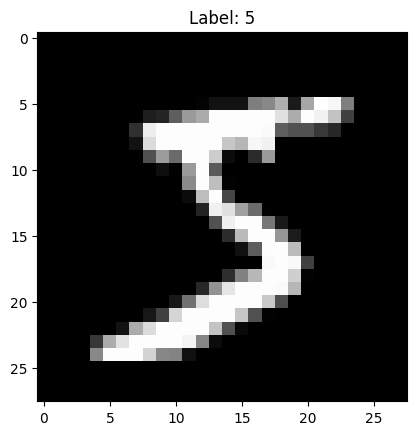

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Chargement des données (Entraînement et Test)
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print(f"Forme des données d'entraînement : {train_images.shape}")
print(f"Nombre de labels : {len(train_labels)}")

# Visualisation d'un exemple
plt.imshow(train_images[0], cmap='gray')
plt.title(f"Label: {train_labels[0]}")
plt.show()

### 2. Approche 1 : Réseau de neurones Fully Connected (Dense)
Pour un réseau dense, nous devons "aplatir" l'image (28x28) en un vecteur unique de 784 pixels.

In [2]:
# Prétraitement pour le modèle Dense
x_train_flat = train_images.reshape((60000, 28 * 28)).astype('float32') / 255
x_test_flat = test_images.reshape((10000, 28 * 28)).astype('float32') / 255

# One-hot encoding des labels (ex: 3 devient [0,0,0,1,0,0,0,0,0,0])
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

# Construction du modèle
model_dense = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(28 * 28,)),
    layers.Dense(10, activation='softmax') # 10 classes pour les chiffres 0-9
])

model_dense.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Entraînement du modèle Dense...")
model_dense.fit(x_train_flat, y_train, epochs=5, batch_size=128, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entraînement du modèle Dense...
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9165 - loss: 0.2981 - val_accuracy: 0.9557 - val_loss: 0.1572
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9639 - loss: 0.1227 - val_accuracy: 0.9674 - val_loss: 0.1105
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9766 - loss: 0.0799 - val_accuracy: 0.9728 - val_loss: 0.0922
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9835 - loss: 0.0560 - val_accuracy: 0.9735 - val_loss: 0.0847
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9879 - loss: 0.0417 - val_accuracy: 0.9758 - val_loss: 0.0794


### 3. Approche 2 : Réseau de neurones Convolutif (CNN)
Le CNN conserve la structure spatiale (2D) de l'image. Nous devons redimensionner les données pour inclure le canal de couleur (1 pour le gris).

In [3]:
# Prétraitement pour le CNN (ajout de la dimension de canal)
x_train_cnn = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
x_test_cnn = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255

# Construction du CNN
model_cnn = models.Sequential([
    # Première couche de convolution : détecte des motifs simples
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)), # Réduit la taille pour gagner en calcul

    # Deuxième couche de convolution : motifs plus complexes
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(), # Transformation en vecteur pour la classification finale
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Entraînement du CNN...")
model_cnn.fit(x_train_cnn, y_train, epochs=5, batch_size=128, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entraînement du CNN...
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 101ms/step - accuracy: 0.9254 - loss: 0.2603 - val_accuracy: 0.9741 - val_loss: 0.0881
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - accuracy: 0.9788 - loss: 0.0695 - val_accuracy: 0.9824 - val_loss: 0.0569
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 92ms/step - accuracy: 0.9851 - loss: 0.0483 - val_accuracy: 0.9844 - val_loss: 0.0519
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 37s 100ms/step - accuracy: 0.9876 - loss: 0.0393 - val_accuracy: 0.9852 - val_loss: 0.0485
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 105ms/step - accuracy: 0.9908 - loss: 0.0296 - val_accuracy: 0.9883 - val_loss: 0.0396


### 4. Comparaison des performances
Enfin, nous évaluons les deux modèles sur les données de test qu'ils n'ont jamais vues.

In [4]:
test_loss_d, test_acc_d = model_dense.evaluate(x_test_flat, y_test, verbose=0)
test_loss_c, test_acc_c = model_cnn.evaluate(x_test_cnn, y_test, verbose=0)

print(f"Précision Modèle Dense : {test_acc_d:.4f}")
print(f"Précision Modèle CNN   : {test_acc_c:.4f}")

print("\nConclusion : Le CNN obtient généralement une meilleure précision car il comprend les relations spatiales entre les pixels.")

Précision Modèle Dense : 0.9787
Précision Modèle CNN   : 0.9895

Conclusion : Le CNN obtient généralement une meilleure précision car il comprend les relations spatiales entre les pixels.
